In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
con = duckdb.connect("../data/processed/lending.duckdb", read_only=True)
df = con.sql("SELECT * FROM cohort").df()
df.shape

(500819, 153)

In [4]:
miss = df.isna().mean().sort_values(ascending = False)
miss.head(40)

total_cu_tl                                   1.000000
sec_app_fico_range_low                        1.000000
sec_app_mths_since_last_major_derog           1.000000
sec_app_collections_12_mths_ex_med            1.000000
sec_app_chargeoff_within_12_mths              1.000000
all_util                                      1.000000
sec_app_num_rev_accts                         1.000000
sec_app_open_act_il                           1.000000
sec_app_revol_util                            1.000000
sec_app_open_acc                              1.000000
sec_app_mort_acc                              1.000000
sec_app_inq_last_6mths                        1.000000
sec_app_earliest_cr_line                      1.000000
sec_app_fico_range_high                       1.000000
revol_bal_joint                               1.000000
inq_fi                                        1.000000
max_bal_bc                                    1.000000
open_rv_24m                                   1.000000
open_rv_12

In [5]:
df.select_dtypes("object").nunique().sort_values(ascending = False).head(15)

/var/folders/vb/79sqx8p52m79d1f7z5j9mwww0000gn/T/ipykernel_15797/942240902.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes("object").nunique().sort_values(ascending = False).head(15)


id                           500819
url                          500819
emp_title                    187677
desc                          74263
title                         37587
zip_code                        908
earliest_cr_line                675
last_credit_pull_d               87
last_pymnt_d                     86
settlement_date                  74
debt_settlement_flag_date        69
addr_state                       51
issue_d                          45
sub_grade                        35
hardship_end_date                17
dtype: int64

In [6]:
df["annual_inc"].describe(percentiles=[.5, .9, .99, .999])

count    5.008190e+05
mean     7.217846e+04
std      6.108529e+04
min      3.000000e+03
50%      6.000000e+04
90%      1.200000e+05
99%      2.500000e+05
99.9%    5.208190e+05
max      8.900060e+06
Name: annual_inc, dtype: float64

In [7]:
df.nlargest(10, "annual_inc")[["annual_inc", "emp_title", "loan_amnt", "grade"]]

,annual_inc,emp_title,loan_amnt,grade
57786,8900060.0,commercial driver,10550.0,D
180498,8706582.0,Correctional Sgt.,8000.0,C
1756,7600000.0,Interim Director of Case Management,10000.0,A
258743,7500000.0,Sales & service rep,15000.0,E
346445,7446395.0,Registered Nurse,20000.0,A
457278,7141778.0,Us postal service,14825.0,B
123443,7000000.0,owner,7500.0,A
450870,6100000.0,BOONE AND SONS JEWELERS,30000.0,B
52145,6000000.0,consultant,4475.0,A
33427,5000000.0,superviser,30000.0,A


top incomes are implausible self-reports; cap at 99.5th percentile in feature engineering (day 2)

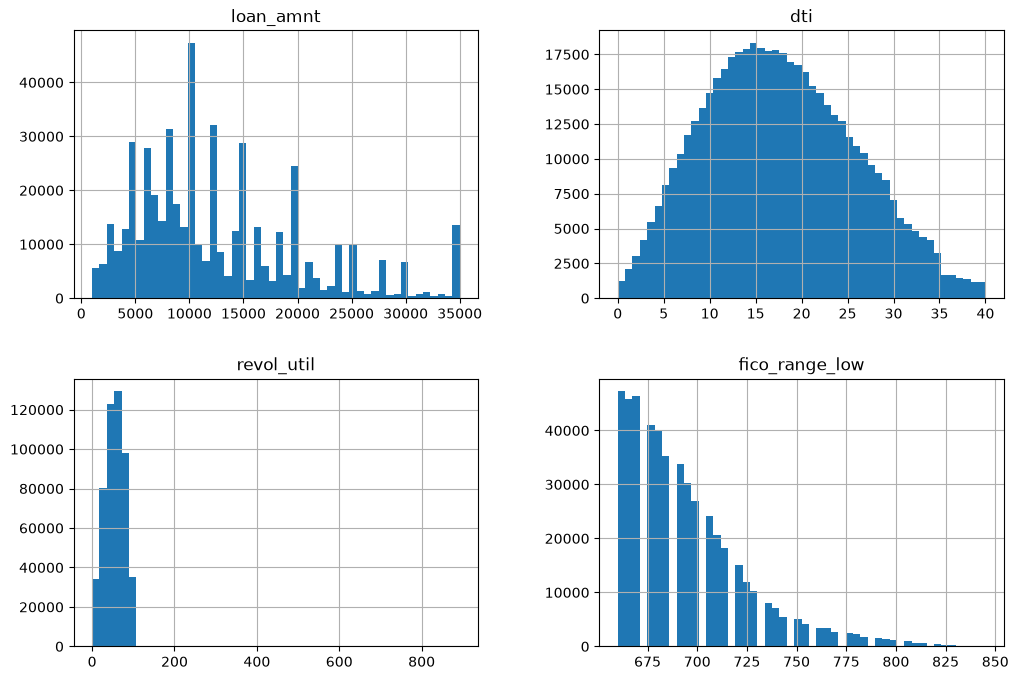

In [8]:
df[["loan_amnt", "dti", "revol_util", "fico_range_low"]].hist(bins=50, figsize=(12, 8));

In [9]:
df["id"].is_unique

True

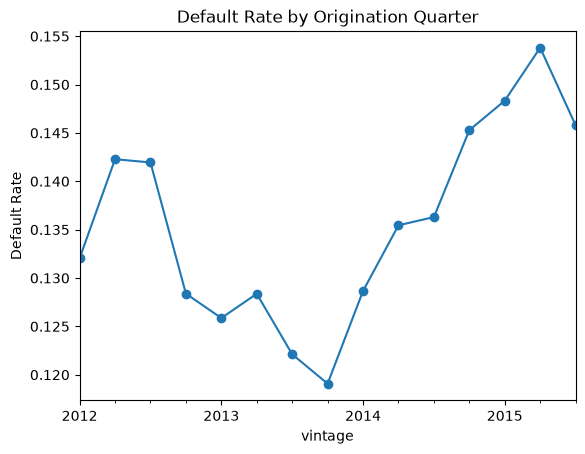

In [10]:
vint = con.sql("""SELECT date_trunc('quarter', issue_date) AS vintage,
                          avg(default_flag) AS default_rate
                   FROM cohort
                   GROUP BY vintage
                   ORDER BY vintage""").df()
vint.plot(x="vintage", y="default_rate", marker="o", legend = False, ylabel = "Default Rate", title="Default Rate by Origination Quarter");

In [11]:
df["revol_util"].describe(percentiles=[.99, .999, .9999])

count     500557.000000
mean          54.549738
std           23.486986
min            0.000000
99%           98.100000
99.9%        102.600000
99.99%       120.483320
max          892.300000
Name: revol_util, dtype: float64

In [16]:
(df["revol_util"] > 120).sum()

np.int64(53)

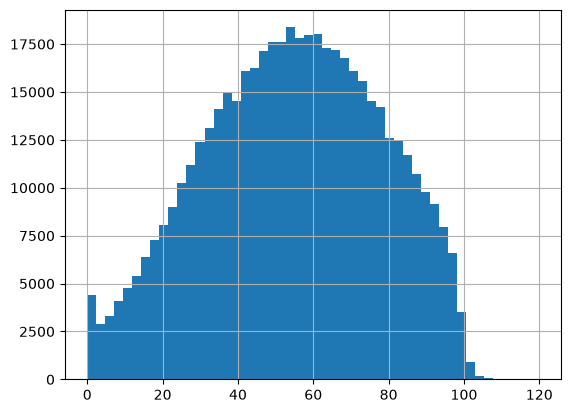

In [17]:
df.loc[df["revol_util"] <= 120, "revol_util"].hist(bins=50);